In [1]:
import sys
print(sys.version)

3.7.0 (default, Jun 28 2018, 08:04:48) [MSC v.1912 64 bit (AMD64)]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

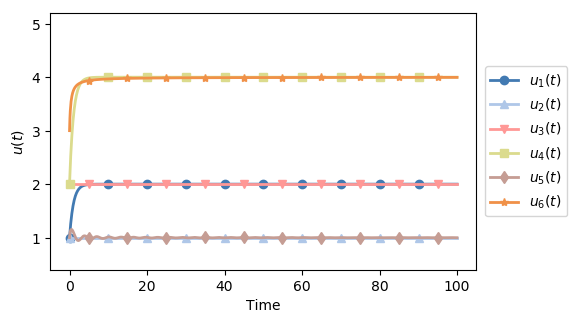

In [3]:
# Figure 1,  (I)-a


t=np.linspace(0,100,1000)
u1=np.zeros(len(t))
u2=np.zeros(len(t))
u3=np.zeros(len(t))
u4=np.zeros(len(t))
u5=np.zeros(len(t))
u6=np.zeros(len(t))


for i in range(len(t)):
    u1[i]=2-np.exp(-t[i])
    u2[i]=1
    u3[i]=2
    u4[i]=4-2*np.exp(-t[i])
    u5[i]=1+np.sin(2*t[i])/(2+7*t[i])
    u6[i]=4-1/(1+3*t[i])


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(t, u1, label='$u_1(t)$',lw=2,color='#427AB2',marker='o',markersize=6,markevery=100)
plt.plot(t, u2, label='$u_2(t)$',lw=2,color='#AFC7E8',marker='^',markersize=6,markevery=100)
plt.plot(t, u3, label='$u_3(t)$',lw=2,color='#FF9896',marker='v',markersize=6,markevery=(49,100))
plt.plot(t, u4, label='$u_4(t)$',lw=2,color='#DBDB8D',marker='s',markersize=6,markevery=100)
plt.plot(t, u5, label='$u_5(t)$',lw=2,color='#C59D94',marker='d',markersize=6,markevery=(49,100))
plt.plot(t, u6, label='$u_6(t)$',lw=2,color='#F09148',marker='*',markersize=6,markevery=(49,100))
plt.xlabel('Time')
plt.ylabel('$u(t)$')
plt.ylim(0.4,5.2)
plt.legend(bbox_to_anchor=(1.02, 0.5), loc=6, borderaxespad=0,ncol=1)
plt.show()

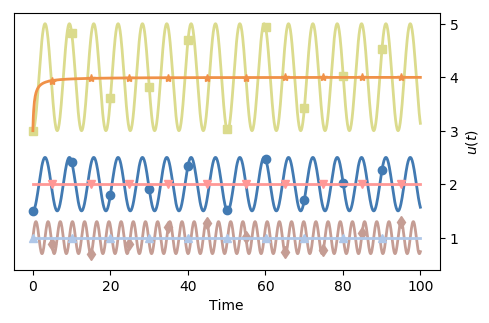

In [4]:
# Figure 1,  (II)-a


t=np.linspace(0,100,1000)
u1=np.zeros(len(t))
u2=np.zeros(len(t))
u3=np.zeros(len(t))
u4=np.zeros(len(t))
u5=np.zeros(len(t))
u6=np.zeros(len(t))


for i in range(len(t)):
    u1[i]=2-0.5*np.cos(t[i])
    u2[i]=1
    u3[i]=2
    u4[i]=4-np.cos(t[i])
    u5[i]=1+0.3*np.sin(2*t[i])
    u6[i]=4-1/(1+3*t[i])


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(t, u1, label='$u_1(t)$',lw=2,color='#427AB2',marker='o',markersize=6,markevery=100)
plt.plot(t, u3, label='$u_3(t)$',lw=2,color='#FF9896',marker='v',markersize=6,markevery=(49,100))
plt.plot(t, u4, label='$u_4(t)$',lw=2,color='#DBDB8D',marker='s',markersize=6,markevery=100)
plt.plot(t, u5, label='$u_5(t)$',lw=2,color='#C59D94',marker='d',markersize=6,markevery=(49,100))
plt.plot(t, u6, label='$u_6(t)$',lw=2,color='#F09148',marker='*',markersize=6,markevery=(49,100))
plt.plot(t, u2, label='$u_2(t)$',lw=2,color='#AFC7E8',marker='^',markersize=6,markevery=100)
plt.xlabel('Time')
plt.ylabel('$u(t)$')
plt.ylim(0.4,5.2)
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.show()

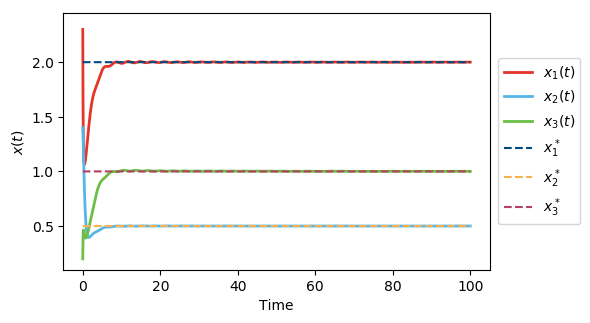

In [5]:
# Figure 1,  (I)-b

def ISSLC(t,state0):
    x1,x2,x3=state0
    u1=2-np.exp(-t)
    u2=1
    u3=2
    u4=4-2*np.exp(-t)
    u5=1+np.sin(2*t)/(2+7*t)
    u6=4-1/(1+3*t)
    dx1=u1-u3*x1*x2-2*u5*x1**2+2*u6*x3
    dx2=u2*x1-u4*x2
    dx3=u5*x1**2-u6*x3
    return [dx1,dx2,dx3]


state0=[2.3,1.4,0.2]
t_span=(0,100)


states=scipy.integrate.solve_ivp(ISSLC, t_span, state0, method='LSODA')
target_1=2
targets_1=np.ones(len(states.t))*target_1
target_2=0.5
targets_2=np.ones(len(states.t))*target_2
target_3=1
targets_3=np.ones(len(states.t))*target_3


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(states.t, states.y[0], label='$x_1(t)$',lw='2',color='#E53528')  
plt.plot(states.t, states.y[1], label='$x_2(t)$',lw='2',color='#55B7E8')
plt.plot(states.t, states.y[2], label='$x_3(t)$',lw='2',color='#6cbe45')
plt.plot(states.t, targets_1, label='$x_1^*$',ls='--',color='#004a80')
plt.plot(states.t, targets_2, label='$x_2^*$',ls='--',color='#fbb050')
plt.plot(states.t, targets_3, label='$x_3^*$',ls='--',color='#b44063')
plt.legend(bbox_to_anchor=(1.02, 0.5), loc=6, borderaxespad=0,ncol=1)
plt.xlabel('Time')
plt.ylabel('$x(t)$')
plt.ylim(0.1,2.45)
plt.show()

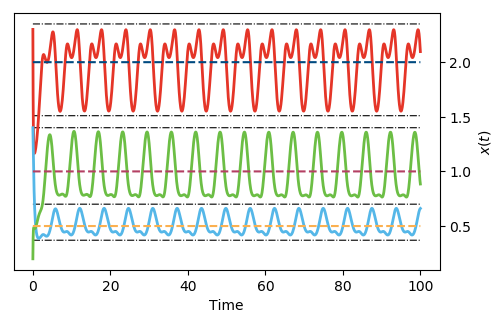

In [6]:
# Figure 1,  (II)-b

def ISSLC(t,state0):
    x1,x2,x3=state0
    u1=2-0.5*np.cos(t)
    u2=1
    u3=2
    u4=4-np.cos(t)
    u5=1+0.3*np.sin(2*t)
    u6=4-1/(1+3*t)
    dx1=u1-u3*x1*x2-2*u5*x1**2+2*u6*x3
    dx2=u2*x1-u4*x2
    dx3=u5*x1**2-u6*x3
    return [dx1,dx2,dx3]


state0=[2.3,1.4,0.2]
t_span=(0,100)


states=scipy.integrate.solve_ivp(ISSLC, t_span, state0, method='LSODA')
target_1=2
targets_1=np.ones(len(states.t))*target_1
target_2=0.5
targets_2=np.ones(len(states.t))*target_2
target_3=1
targets_3=np.ones(len(states.t))*target_3

line1=np.ones(len(states.t))*2.35
line2=np.ones(len(states.t))*1.51
line3=np.ones(len(states.t))*1.4
line4=np.ones(len(states.t))*0.7
line5=np.ones(len(states.t))*0.37


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(states.t, line1, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line2, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line3, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line4, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line5, ls='-.',lw=0.8,color='black')
plt.plot(states.t, states.y[0], label='$x_1(t)$',lw='2',color='#E53528')  
plt.plot(states.t, states.y[1], label='$x_2(t)$',lw='2',color='#55B7E8')
plt.plot(states.t, states.y[2], label='$x_3(t)$',lw='2',color='#6cbe45')
plt.plot(states.t, targets_1, label='$x_1^*$',ls='--',color='#004a80')
plt.plot(states.t, targets_2, label='$x_2^*$',ls='--',color='#fbb050')
plt.plot(states.t, targets_3, label='$x_3^*$',ls='--',color='#b44063')
plt.xlabel('Time')
plt.ylabel('$x(t)$')
plt.ylim(0.1,2.45)
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.show()

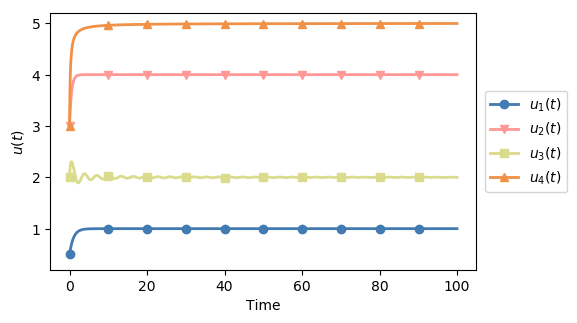

In [7]:
# Figure 2,  (I)-a


t=np.linspace(0,100,1000)
u1=np.zeros(len(t))
u2=np.zeros(len(t))
u3=np.zeros(len(t))
u4=np.zeros(len(t))


for i in range(len(t)):
    u1[i]=1-0.5*np.exp(-t[i])
    u2[i]=4-np.exp(-2*t[i])
    u3[i]=2+2*np.sin(2*t[i])/(2+7*t[i])
    u4[i]=5-2/(1+5*t[i])


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(t, u1, label='$u_1(t)$',lw=2,color='#427AB2',marker='o',markersize=6,markevery=100)
plt.plot(t, u2, label='$u_2(t)$',lw=2,color='#FF9896',marker='v',markersize=6,markevery=100)
plt.plot(t, u3, label='$u_3(t)$',lw=2,color='#DBDB8D',marker='s',markersize=6,markevery=100)
plt.plot(t, u4, label='$u_4(t)$',lw=2,color='#F09148',marker='^',markersize=6,markevery=100)
plt.xlabel('Time')
plt.ylabel('$u(t)$')
plt.ylim(0.2,5.2)
plt.legend(bbox_to_anchor=(1.02, 0.5), loc=6, borderaxespad=0,ncol=1)
plt.show()

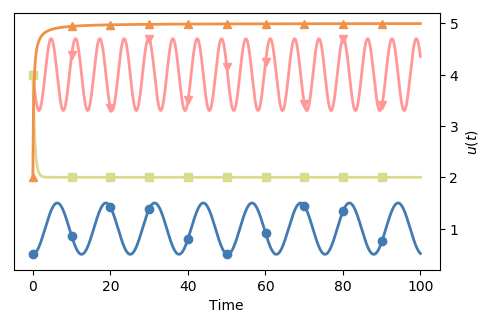

In [8]:
# Figure 2,  (II)-a


t=np.linspace(0,100,1000)
u1=np.zeros(len(t))
u2=np.zeros(len(t))
u3=np.zeros(len(t))
u4=np.zeros(len(t))


for i in range(len(t)):
    u1[i]=1-0.5*np.cos(0.5*t[i])
    u2[i]=4-0.7*np.sin(t[i])
    u3[i]=2+2*np.exp(-2*t[i])
    u4[i]=5-3/(1+5*t[i])


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(t, u1, label='$u_1(t)$',lw=2,color='#427AB2',marker='o',markersize=6,markevery=100)
plt.plot(t, u2, label='$u_2(t)$',lw=2,color='#FF9896',marker='v',markersize=6,markevery=100)
plt.plot(t, u3, label='$u_3(t)$',lw=2,color='#DBDB8D',marker='s',markersize=6,markevery=100)
plt.plot(t, u4, label='$u_4(t)$',lw=2,color='#F09148',marker='^',markersize=6,markevery=100)

plt.xlabel('Time')
plt.ylabel('$u(t)$')
plt.ylim(0.2,5.2)
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.show()

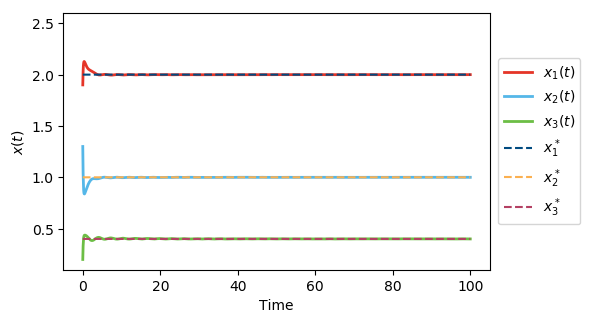

In [9]:
# Figure 2,  (I)-b

def ISSLC(t,state0):
    x1,x2,x3=state0
    u1=1-0.5*np.exp(-t)
    u2=4-np.exp(-2*t)
    u3=2+2*np.sin(2*t)/(2+7*t)
    u4=5-2/(1+5*t)
    dx1=-u1*x1**2+u2*x2
    dx2=u1*x1**2-u2*x2-u3*x2+u4*x3
    dx3=u3*x2-u4*x3
    return [dx1,dx2,dx3]


state0=[1.9,1.3,0.2]
t_span=(0,100)


states=scipy.integrate.solve_ivp(ISSLC, t_span, state0, method='LSODA')
target_1=2
targets_1=np.ones(len(states.t))*target_1
target_2=1
targets_2=np.ones(len(states.t))*target_2
target_3=0.4
targets_3=np.ones(len(states.t))*target_3


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(states.t, states.y[0], label='$x_1(t)$',lw='2',color='#E53528')  
plt.plot(states.t, states.y[1], label='$x_2(t)$',lw='2',color='#55B7E8')
plt.plot(states.t, states.y[2], label='$x_3(t)$',lw='2',color='#6cbe45')
plt.plot(states.t, targets_1, label='$x_1^*$',ls='--',color='#004a80')
plt.plot(states.t, targets_2, label='$x_2^*$',ls='--',color='#fbb050')
plt.plot(states.t, targets_3, label='$x_3^*$',ls='--',color='#b44063')
plt.legend(bbox_to_anchor=(1.02, 0.5), loc=6, borderaxespad=0,ncol=1)
plt.xlabel('Time')
plt.ylabel('$x(t)$')
plt.ylim(0.1,2.6)
plt.show()

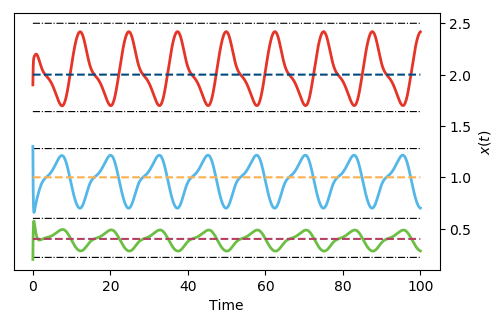

In [10]:
# Figure 2,  (II)-b

def ISSLC(t,state0):
    x1,x2,x3=state0
    u1=1-0.5*np.cos(0.5*t)
    u2=4-0.7*np.sin(t)
    u3=2+2*np.exp(-2*t)
    u4=5-3/(1+5*t)
    dx1=-u1*x1**2+u2*x2
    dx2=u1*x1**2-u2*x2-u3*x2+u4*x3
    dx3=u3*x2-u4*x3
    return [dx1,dx2,dx3]


state0=[1.9,1.3,0.2]
t_span=(0,100)


states=scipy.integrate.solve_ivp(ISSLC, t_span, state0, method='LSODA')
target_1=2
targets_1=np.ones(len(states.t))*target_1
target_2=1
targets_2=np.ones(len(states.t))*target_2
target_3=0.4
targets_3=np.ones(len(states.t))*target_3
line1=np.ones(len(states.t))*2.5
line2=np.ones(len(states.t))*1.64
line3=np.ones(len(states.t))*1.28
line4=np.ones(len(states.t))*0.6
line5=np.ones(len(states.t))*0.22


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(states.t, line1, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line2, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line3, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line4, ls='-.',lw=0.8,color='black')
plt.plot(states.t, line5, ls='-.',lw=0.8,color='black')
plt.plot(states.t, states.y[0], label='$x_1(t)$',lw='2',color='#E53528')  
plt.plot(states.t, states.y[1], label='$x_2(t)$',lw='2',color='#55B7E8')
plt.plot(states.t, states.y[2], label='$x_3(t)$',lw='2',color='#6cbe45')
plt.plot(states.t, targets_1, label='$x_1^*$',ls='--',color='#004a80')
plt.plot(states.t, targets_2, label='$x_2^*$',ls='--',color='#fbb050')
plt.plot(states.t, targets_3, label='$x_3^*$',ls='--',color='#b44063')
plt.xlabel('Time')
plt.ylabel('$x(t)$')
plt.ylim(0.1,2.6)
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.show()

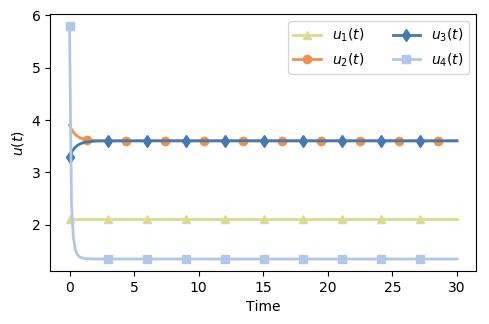

In [11]:
# Figure 3  (a)


def ISSu(t,state0):
    u1,u2,u3,u4=state0
    du1=0
    du2=u3-u2
    du3=u2-u3
    du4=u2-2*u4*u4
    return [du1,du2,du3,du4]


state0=[2.1,3.9,3.3,5.8]
t_span=(0,30)
dt=np.linspace(0,30,200)

states=scipy.integrate.solve_ivp(ISSu, t_span, state0, method='LSODA',t_eval=dt)


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(states.t, states.y[0], label='$u_1(t)$',lw='2',color='#DBDB8D',marker='^',markersize=6,markevery=20)  
plt.plot(states.t, states.y[1], label='$u_2(t)$',lw='2',color='#F09148',marker='o',markersize=6,markevery=(9,20))
plt.plot(states.t, states.y[2], label='$u_3(t)$',lw='2',color='#427AB2',marker='d',markersize=6,markevery=20)  
plt.plot(states.t, states.y[3], label='$u_4(t)$',lw='2',color='#AFC7E8',marker='s',markersize=6,markevery=20)
plt.xlabel('Time')
plt.ylabel('$u(t)$')
plt.legend(ncol=2)
plt.show()

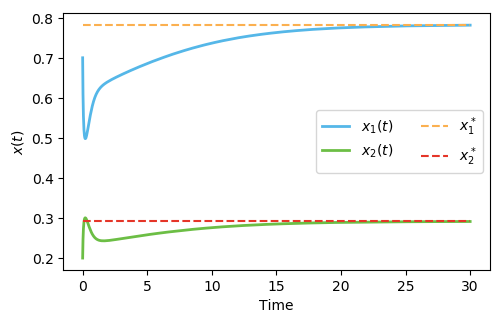

In [12]:
# Figure 3  (b)

def ISSLC(t,state0):
    x1,x2,u1,u2,u3,u4=state0
    dx1=2*u3*x1*x2-2*u4*x1**2
    dx2=u1*x1*x2**2-2*u2*x1*x2**3-u3*x1*x2+u4*x1**2
    du1=0
    du2=u3-u2
    du3=u2-u3
    du4=u2-2*u4*u4
    return [dx1,dx2,du1,du2,du3,du4]


state0=[0.7,0.2,2.1,3.9,3.3,5.8]
t_span=(0,30)
eu1=2.1
eu2=3.6
eu3=3.6
eu4=np.sqrt(1.8)


states=scipy.integrate.solve_ivp(ISSLC, t_span, state0, method='LSODA')
target_1=eu1*eu3/eu2/eu4/2
targets_1=np.ones(len(states.t))*target_1
target_2=eu1/eu2/2
targets_2=np.ones(len(states.t))*target_2


plt.figure(figsize=(5.5,3.4),dpi=100)
plt.plot(states.t, states.y[0], label='$x_1(t)$',lw='2',color='#55B7E8')  
plt.plot(states.t, states.y[1], label='$x_2(t)$',lw='2',color='#6cbe45')
plt.plot(states.t, targets_1, label='$x_1^*$',ls='--',color='#fbb050')
plt.plot(states.t, targets_2, label='$x_2^*$',ls='--',color='#E53528')
plt.legend(loc=0,ncol=2)
plt.xlabel('Time')
plt.ylabel('$x(t)$')
plt.show()